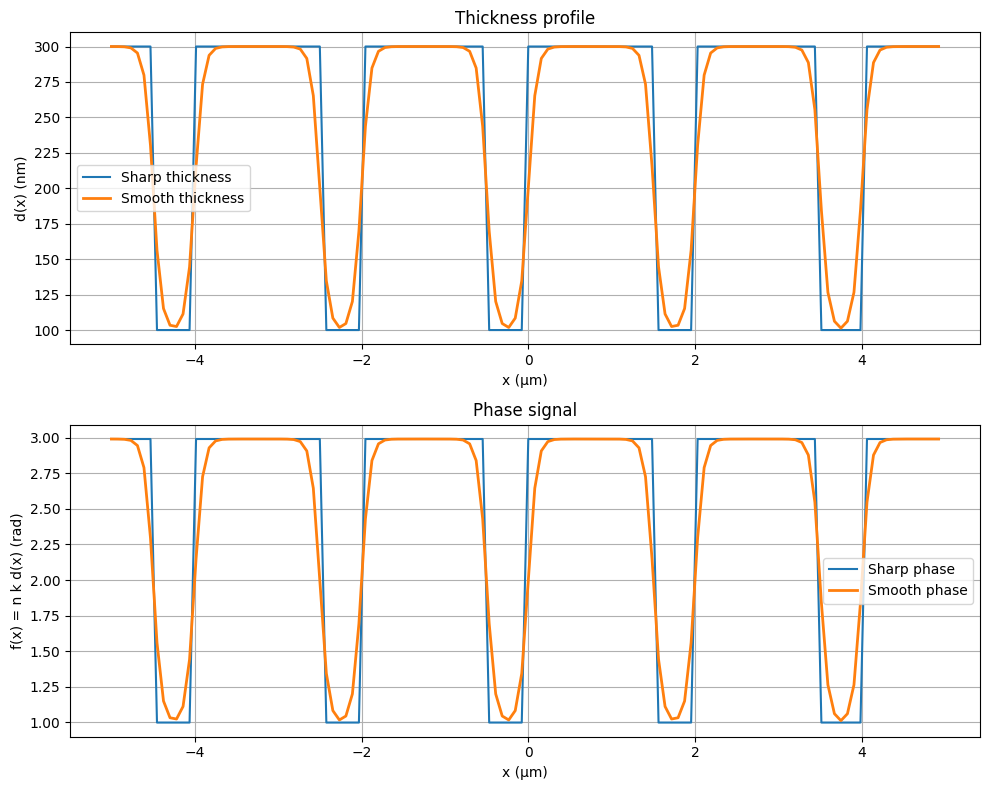

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def spatial_grid(L, Nx):
    return np.linspace(-L/2, L/2, Nx, endpoint=False)

def smooth_step(z, k):
    return 0.5 * (1 + np.tanh(k * z))

def thickness_profile_sharp(x, Lambda, duty, d0, h):
    phase = (x % Lambda) / Lambda
    return d0 + h * (phase < duty).astype(float)

def thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=40):
    """
    Periodic smooth rectangular profile.
    
    phase in [0,1)
    high region: 0 <= phase < duty
    smooth transitions at phase = 0 and phase = duty
    """
    phase = (x % Lambda) / Lambda

    # periodic distance from the center of the high region
    center = duty / 2
    u = phase - center
    u = (u + 0.5) % 1.0 - 0.5   # wrap to [-0.5, 0.5)

    halfwidth = duty / 2

    # smooth top-hat
    pulse = 0.5 * (1 - np.tanh(k * (np.abs(u) - halfwidth)))

    return d0 + h * pulse

def phase_signal(d, n, lam):
    k0 = 2 * np.pi / lam
    return n * k0 * d

def plot_profiles(x, d_sharp, d_smooth, f_sharp, f_smooth):
    plt.figure(figsize=(10, 8))

    plt.subplot(2, 1, 1)
    plt.plot(x * 1e6, d_sharp * 1e9, label="Sharp thickness", linewidth=1.5)
    plt.plot(x * 1e6, d_smooth * 1e9, label="Smooth thickness", linewidth=2)
    plt.xlabel("x (µm)")
    plt.ylabel("d(x) (nm)")
    plt.title("Thickness profile")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(x * 1e6, f_sharp, label="Sharp phase", linewidth=1.5)
    plt.plot(x * 1e6, f_smooth, label="Smooth phase", linewidth=2)
    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title("Phase signal")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# -----------------------------
# Parameters
# -----------------------------
L = 10e-6
Nx = 128

lam = 630e-9
n = 1.0

Lambda = 2e-6
duty = 0.75
d0 = 100e-9
h = 200e-9

smoothness_k = 20   # increase for sharper edges

# -----------------------------
# Build profiles
# -----------------------------
x = spatial_grid(L, Nx)

d_sharp = thickness_profile_sharp(x, Lambda, duty, d0, h)
d_smooth = thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=smoothness_k)

f_sharp = phase_signal(d_sharp, n, lam)
f_smooth = phase_signal(d_smooth, n, lam)

# -----------------------------
# Plot
# -----------------------------
plot_profiles(x, d_sharp, d_smooth, f_sharp, f_smooth)

In [13]:
import numpy as np

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha

In [16]:
# compute phi for smoothed signal
phi_smooth, alpha_smooth = phi_from_f(f_smooth)

print("alpha (smooth) =", alpha_smooth)
print("check normalization =", np.sum(phi_smooth**2))
print("phi (smooth) =", phi_smooth)

alpha (smooth) = 319.05950767810634
check normalization = 1.0
phi (smooth) = [0.09683623 0.0968307  0.09680437 0.09667922 0.09609314 0.09352474
 0.08484054 0.06989355 0.06000074 0.0568471  0.05660005 0.05899169
 0.06721681 0.08207417 0.09244613 0.09582712 0.09662141 0.09679216
 0.09682814 0.09683569 0.09683727 0.09683761 0.09683768 0.09683767
 0.09683757 0.09683712 0.09683496 0.09682464 0.09677548 0.09654268
 0.09546947 0.09107247 0.07906765 0.06487828 0.05821483 0.05641717
 0.05717949 0.06129036 0.07283865 0.08728275 0.09435728 0.09629015
 0.09672163 0.09681331 0.09683258 0.09683662 0.09683747 0.09683765
 0.09683768 0.09683765 0.09683747 0.09683662 0.09683258 0.09681331
 0.09672163 0.09629015 0.09435728 0.08728275 0.07283865 0.06129036
 0.05717949 0.05641717 0.05821483 0.06487828 0.07906765 0.09107247
 0.09546947 0.09654268 0.09677548 0.09682464 0.09683496 0.09683712
 0.09683757 0.09683767 0.09683768 0.09683761 0.09683727 0.09683569
 0.09682814 0.09679216 0.09662141 0.09582712 0.09244

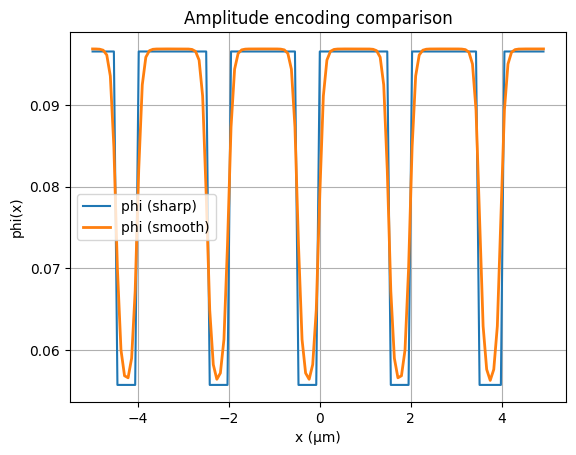

In [18]:
phi_sharp, _ = phi_from_f(f)

plt.figure()
plt.plot(x*1e6, phi_sharp, label="phi (sharp)")
plt.plot(x*1e6, phi_smooth, label="phi (smooth)", linewidth=2)
plt.xlabel("x (µm)")
plt.ylabel("phi(x)")
plt.title("Amplitude encoding comparison")
plt.legend()
plt.grid(True)
plt.show()

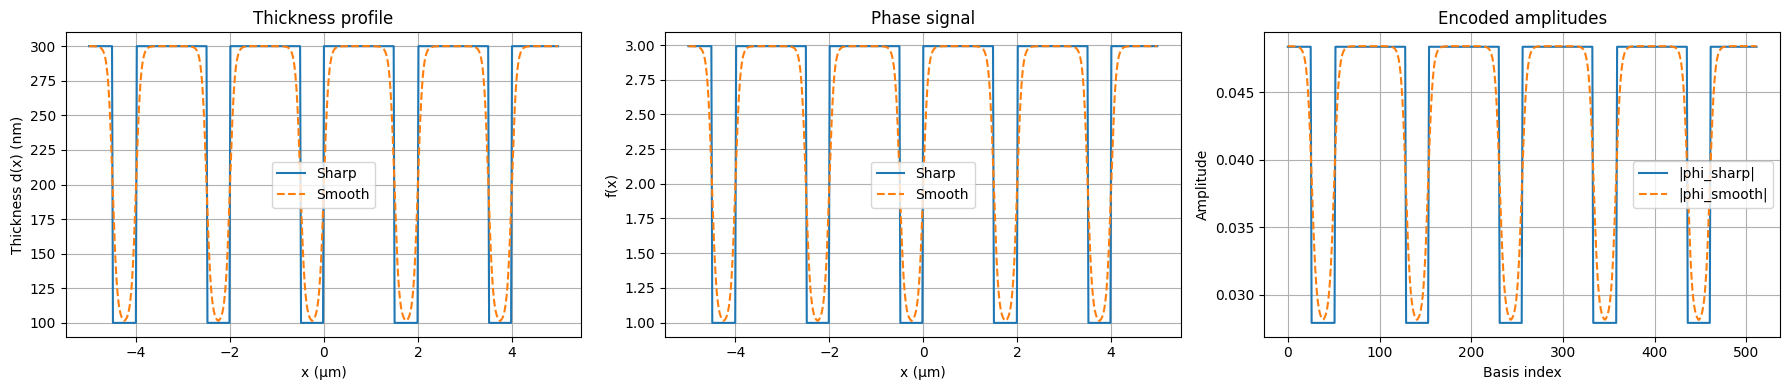

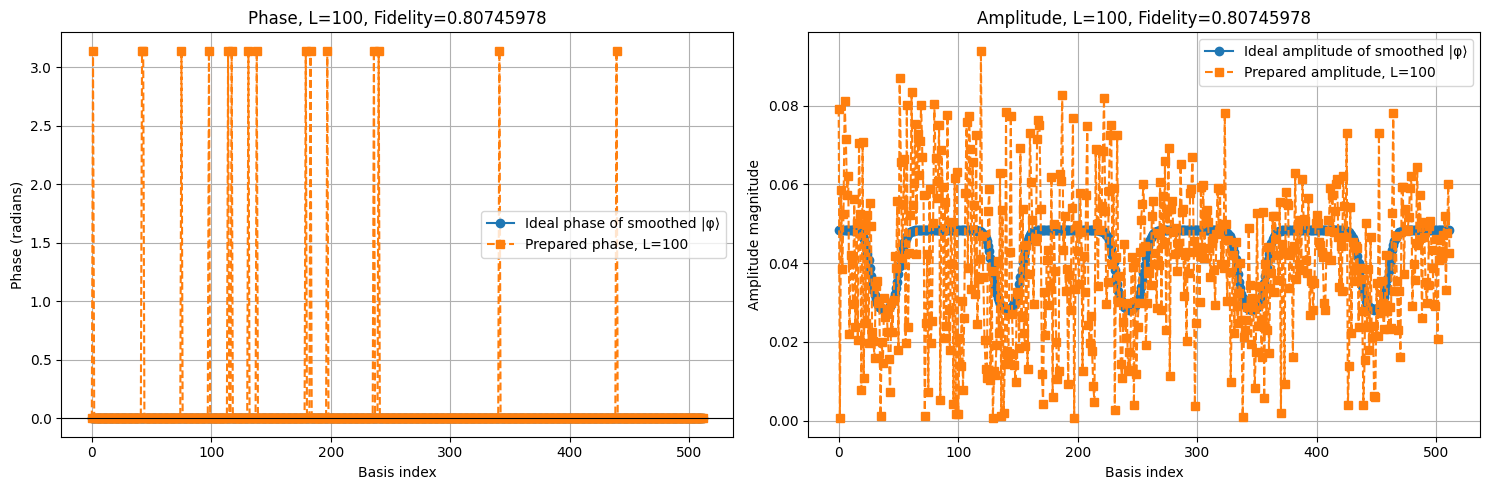

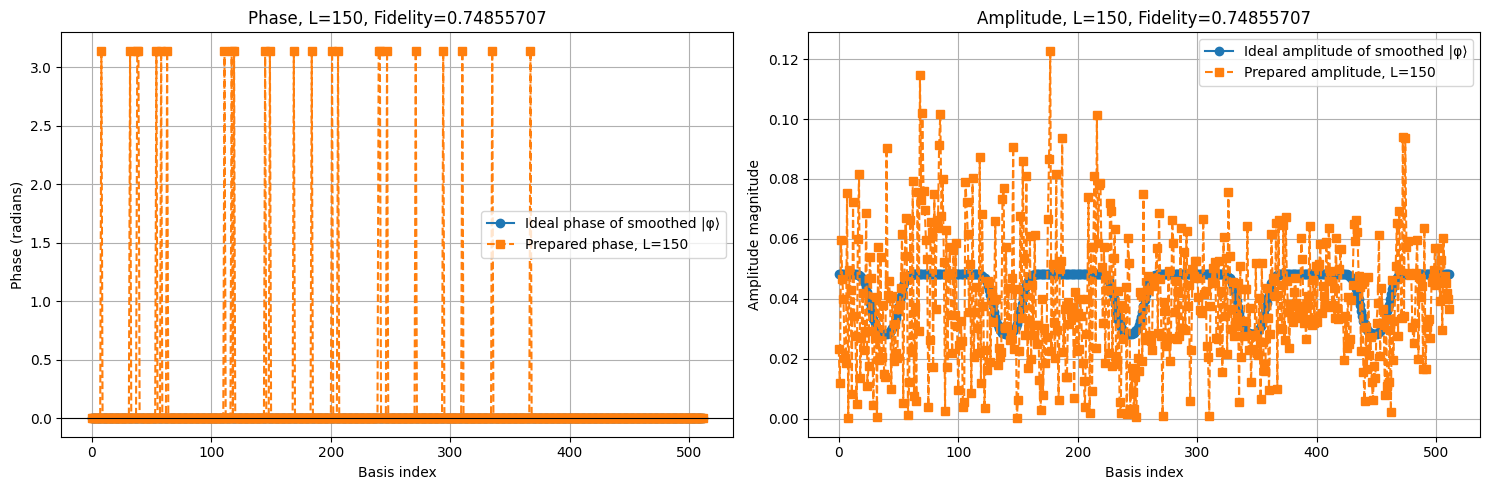

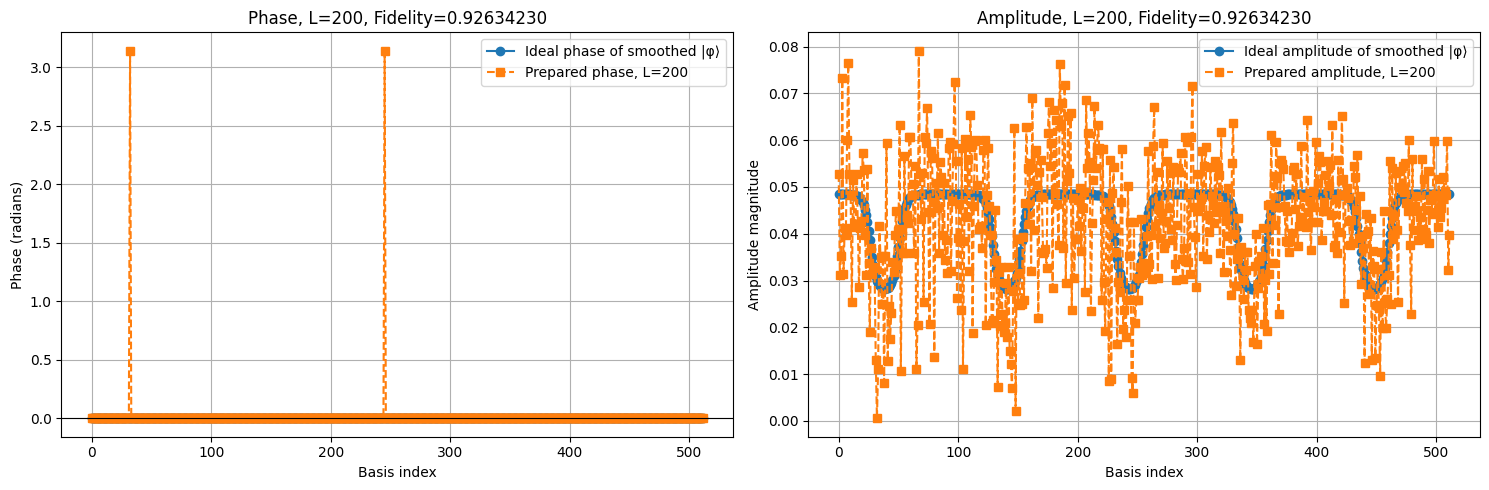

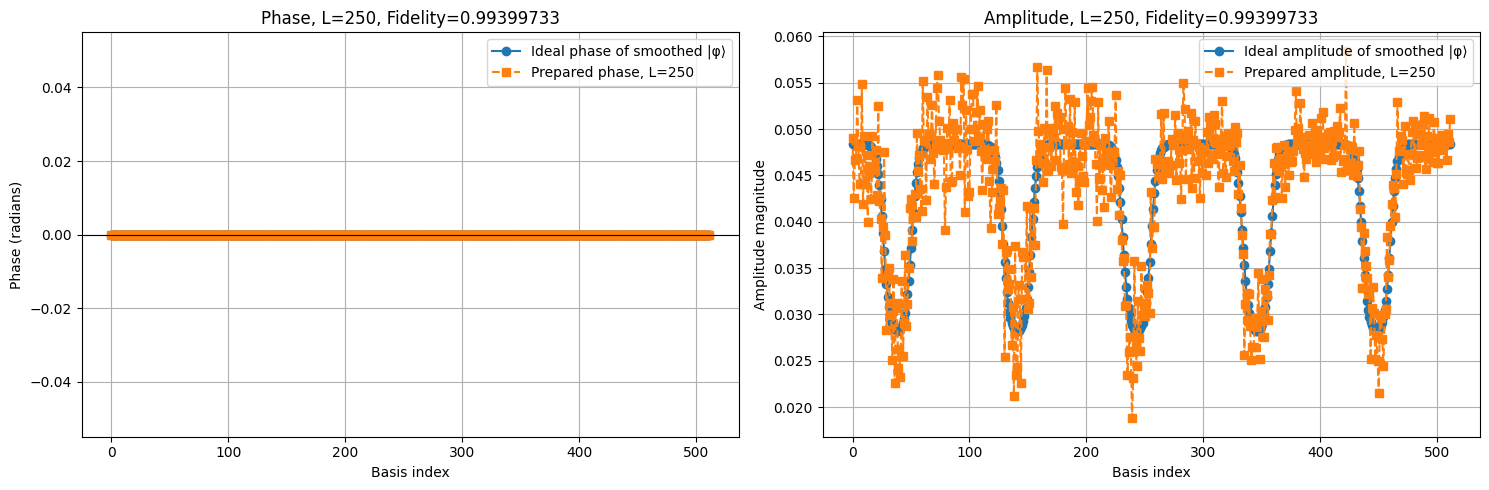

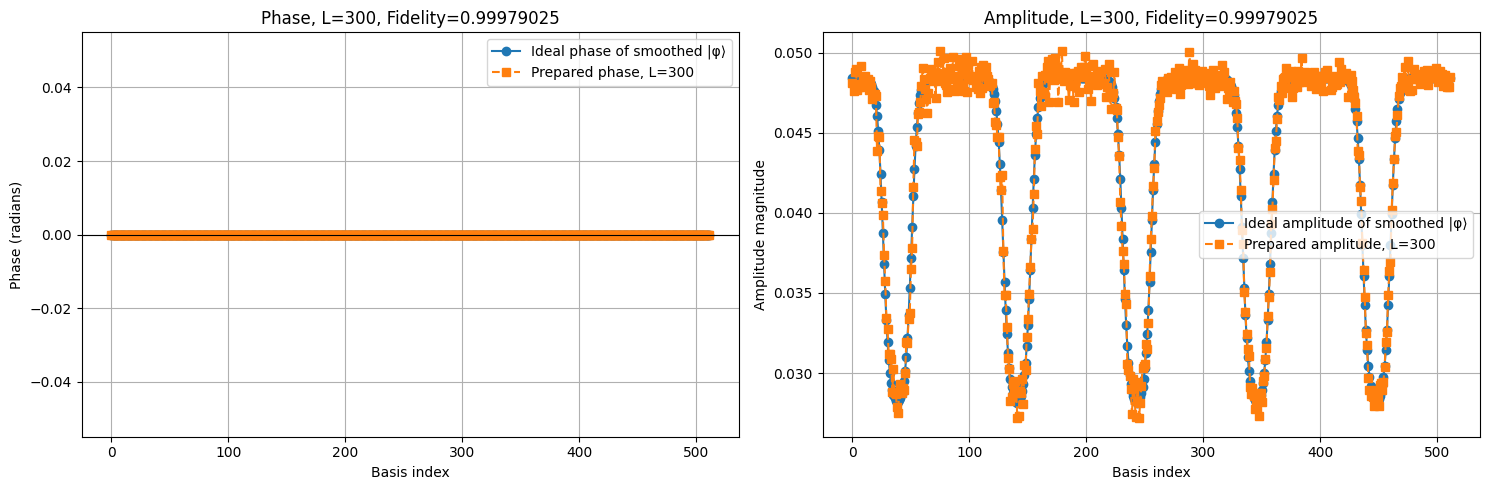

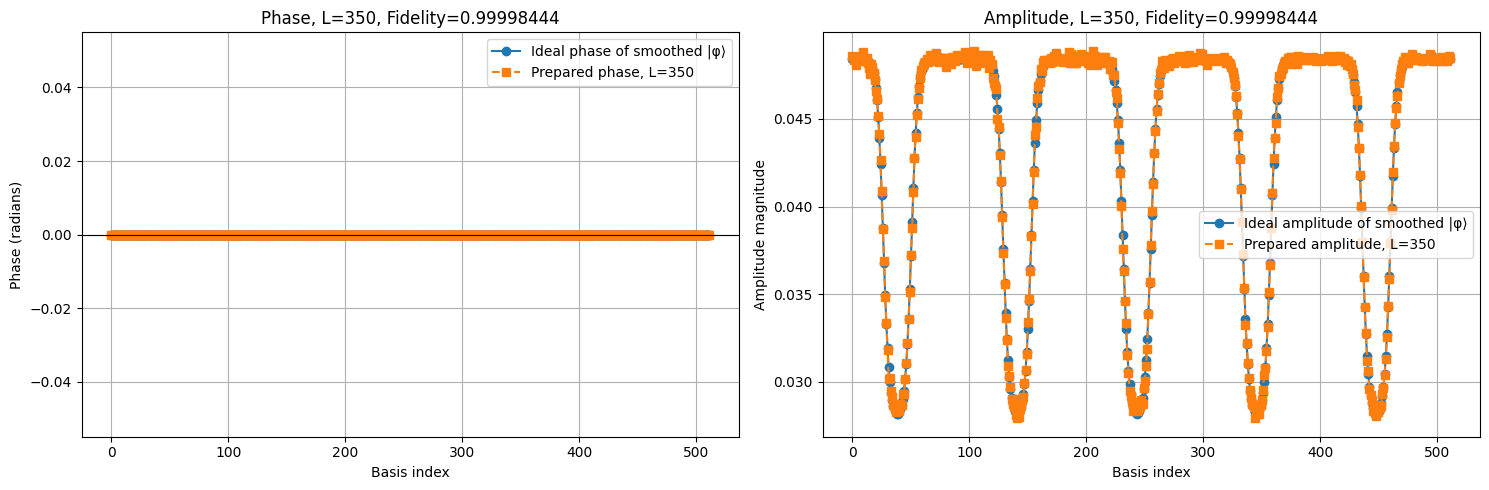

alpha_sharp  = 1278.5783434609884
alpha_smooth = 1276.240616267647
check normalization of phi_smooth = 1.0

Layer-wise fidelities for smoothed target state:
L = 100, Fidelity = 0.80745978
L = 400, Fidelity = 0.74855707
L =  50, Fidelity = 0.92634230


In [24]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity


# ----------------------------
# 1. Classical profile
# ----------------------------
def spatial_grid(L, Nx):
    return np.linspace(-L/2, L/2, Nx, endpoint=False)

def thickness_profile_sharp(x, Lambda, duty, d0, h):
    phase = (x % Lambda) / Lambda
    return d0 + h * (phase < duty).astype(float)

def thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=30):
    phase = (x % Lambda) / Lambda

    center = duty / 2
    u = phase - center
    u = (u + 0.5) % 1.0 - 0.5   # wrapped to [-0.5, 0.5)

    halfwidth = duty / 2
    pulse = 0.5 * (1 - np.tanh(k * (np.abs(u) - halfwidth)))

    return d0 + h * pulse

def phase_signal(d, n_medium, lam):
    k0 = 2 * np.pi / lam
    return n_medium * k0 * d

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha


# ----------------------------
# 2. Parameters
# ----------------------------
Lx = 10e-6
Nx = 512

lam = 630e-9
n_medium = 1.0

Lambda = 2e-6
duty = 0.75
d0 = 100e-9
h = 200e-9

smoothness_k = 20


# ----------------------------
# 3. Build sharp + smooth curves
# ----------------------------
x = spatial_grid(Lx, Nx)

d_sharp = thickness_profile_sharp(x, Lambda, duty, d0, h)
d_smooth = thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=smoothness_k)

f_sharp = phase_signal(d_sharp, n_medium, lam)
f_smooth = phase_signal(d_smooth, n_medium, lam)

phi_sharp, alpha_sharp = phi_from_f(f_sharp)
phi_smooth, alpha_smooth = phi_from_f(f_smooth)

# choose which one to simulate
phi_target = np.asarray(phi_smooth, dtype=complex)
phi_target = phi_target / np.linalg.norm(phi_target)

N = len(phi_target)
n = int(np.log2(N))
assert 2**n == N, "Length of phi_target must be a power of 2."


# ----------------------------
# 4. Plot classical signals first
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(x * 1e6, d_sharp * 1e9, label="Sharp")
axes[0].plot(x * 1e6, d_smooth * 1e9, '--', label="Smooth")
axes[0].set_xlabel("x (µm)")
axes[0].set_ylabel("Thickness d(x) (nm)")
axes[0].set_title("Thickness profile")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(x * 1e6, f_sharp, label="Sharp")
axes[1].plot(x * 1e6, f_smooth, '--', label="Smooth")
axes[1].set_xlabel("x (µm)")
axes[1].set_ylabel("f(x)")
axes[1].set_title("Phase signal")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(range(N), np.abs(phi_sharp), label="|phi_sharp|")
axes[2].plot(range(N), np.abs(phi_smooth), '--', label="|phi_smooth|")
axes[2].set_xlabel("Basis index")
axes[2].set_ylabel("Amplitude")
axes[2].set_title("Encoded amplitudes")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()


# ----------------------------
# 5. Qiskit simulation
# ----------------------------
sim = AerSimulator(method="statevector")


fidelities = []

amps_ideal = np.abs(phi_target)
phases_ideal = np.unwrap(np.angle(phi_target))

for L in range(100, 400, 50):
    phi_state = QuantumState.from_dense_data(data=phi_target, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=L)

    qc = QuantumCircuit(n)
    qc.append(U_phi, range(n))
    qc.save_statevector()

    result = sim.run(transpile(qc, sim)).result()
    vec_sim = np.array(result.get_statevector(qc), dtype=complex)

    # fidelity
    F = state_fidelity(vec_sim, phi_target)
    fidelities.append(F)

    # global phase alignment
    global_phase = np.angle(np.vdot(phi_target, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    amps_sim = np.abs(vec_sim_aligned)
    phases_sim = np.unwrap(np.angle(vec_sim_aligned))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Phase
    axes[0].plot(range(N), phases_ideal, 'o-', label="Ideal phase of smoothed |φ⟩")
    axes[0].plot(range(N), phases_sim, 's--', label=f"Prepared phase, L={L}")
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel("Basis index")
    axes[0].set_ylabel("Phase (radians)")
    axes[0].set_title(f"Phase, L={L}, Fidelity={F:.8f}")
    axes[0].legend()
    axes[0].grid(True)

    # Amplitude
    axes[1].plot(range(N), amps_ideal, 'o-', label="Ideal amplitude of smoothed |φ⟩")
    axes[1].plot(range(N), amps_sim, 's--', label=f"Prepared amplitude, L={L}")
    axes[1].set_xlabel("Basis index")
    axes[1].set_ylabel("Amplitude magnitude")
    axes[1].set_title(f"Amplitude, L={L}, Fidelity={F:.8f}")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


# ----------------------------
# 6. Fidelity summary
# ----------------------------
print("alpha_sharp  =", alpha_sharp)
print("alpha_smooth =", alpha_smooth)
print("check normalization of phi_smooth =", np.sum(np.abs(phi_smooth)**2))

print("\nLayer-wise fidelities for smoothed target state:")
for L, F in zip(layer_values, fidelities):
    print(f"L = {L:3d}, Fidelity = {F:.8f}")